# About Dataset

The Credit Card Fraud Detection dataset contains credit card transactions made by customers.

Each row represents one financial transaction.

The dataset includes both normal and fraudulent transactions.

The target column is **Class**, where:

- 0 = Normal Transaction
- 1 = Fraudulent Transaction

The dataset is highly imbalanced because fraudulent transactions are much fewer than normal transactions.

This dataset is commonly used for machine learning projects related to fraud detection.

#### Import Libraries

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Import Libraries

In this step, we import the required Python libraries for data analysis, visualization, and machine learning.

- pandas → Data handling
- numpy → Numerical operations
- matplotlib → Graphs
- seaborn → Statistical visualizations

In [9]:
## Load Dataset

fraud_data = pd.read_csv("creditcard.csv")


In [21]:
fraud_data.head()

#The dataset is loaded into a pandas DataFrame.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [23]:
#Dataset Information
fraud_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Dataset Information

The info() function provides:

- Number of rows
- Number of columns
- Data types
- Missing values

It helps us understand the overall structure of the dataset.

- Check Missing Values

In [33]:
fraud_data.isnull().sum() 

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Missing Values

This code checks the number of missing values in each column.

A value of 0 means there are no missing values in that column.

#### Descriptive Statistics

In [38]:
fraud_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Descriptive Statistics

The describe() function shows summary statistics such as:

- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

This helps us understand the distribution of numerical features.

### Check Class Distribution

In [45]:
fraud_data["class"].value_counts()

KeyError: 'class'

In [47]:
fraud_data["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

Ye output batata hai ki dataset me kitni Normal aur kitni Fraud transactions hain.

0 = Normal Transaction

1 = Fraud Transaction

Dataset me:

284,315 Normal Transactions hain.

Sirf 492 Fraud Transactions hain.

Isse pata chalta hai ki fraud transactions bahut kam hain.

In [49]:
#Fraud Percentage
fraud_data["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

## Fraud Percentage

About 99.83% of transactions are normal.

Only 0.17% of transactions are fraudulent.

This shows that the dataset is highly imbalanced.

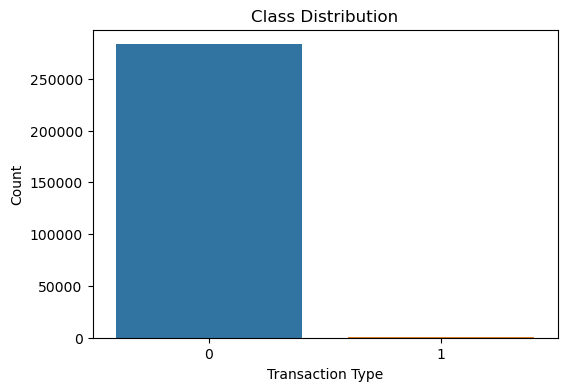

In [68]:
#Plot Class Distribution
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=fraud_data)

plt.title("Class Distribution")

plt.xlabel("Transaction Type")D

plt.ylabel("Count")

plt.show()

graph batata hai ki dataset me Normal aur Fraud transactions kitni hain.

0 = Normal Transaction
1 = Fraud Transaction

Graph me Class 0 ki bar bahut badi hai, kyunki normal transactions bahut zyada hain.

Class 1 ki bar bahut chhoti hai, kyunki fraud transactions bahut kam hain.

Is graph se clearly pata chalta hai ki dataset Highly Imbalanced hai.

In [56]:
fraud_data.duplicated().sum() 

1081

In [60]:
fraud_data = fraud_data.drop_duplicates()

print("Duplicate rows removed successfully.")

Duplicate rows removed successfully.


In [62]:
fraud_data.duplicated().sum()

0

In [64]:
print("Rows after removing duplicates:", fraud_data.shape)

Rows after removing duplicates: (283726, 31)


In [66]:
before_rows = 284807

after_rows = fraud_data.shape[0]

print("Rows Before:", before_rows)
print("Rows After :", after_rows)
print("Removed Rows:", before_rows - after_rows)

Rows Before: 284807
Rows After : 283726
Removed Rows: 1081


#### EDA Distribution of Transaction Amounts (Fraud vs Non-Fraud)

C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


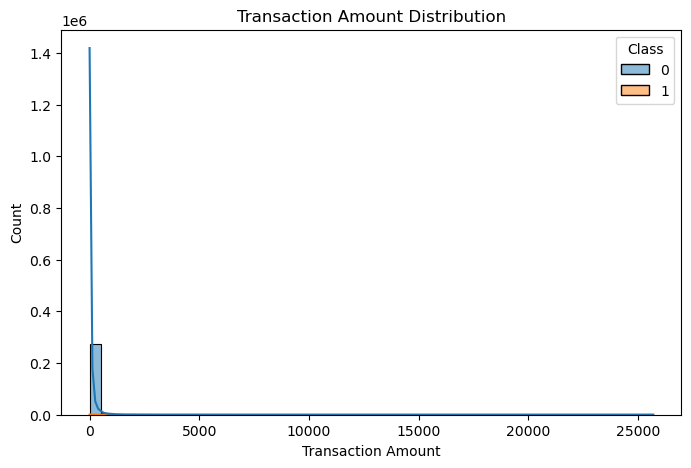

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(data=fraud_data,
             x="Amount",
             hue="Class",
             bins=50,
             kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")

plt.show()

#### Time-of-Day Analysis

In [97]:
fraud_data["Hour"] = (fraud_data["Time"] // 3600) % 24

fraud_data["Hour"].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Hour, dtype: float64

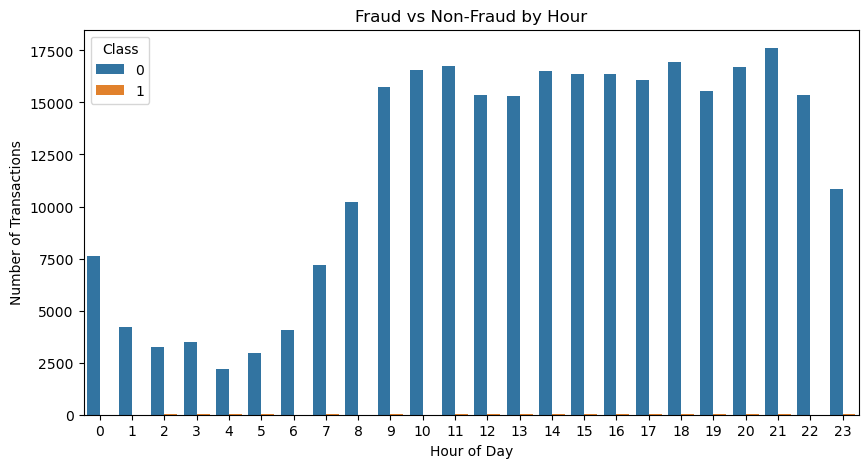

In [91]:
plt.figure(figsize=(10,5))

sns.countplot(data=fraud_data,
              x="Hour",
              hue="Class")

plt.title("Fraud vs Non-Fraud by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

In [79]:
fraud_data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Hour'],
      dtype='object')

In [109]:
fraud_data["Hour"].value_counts().sort_index()

Hour
0      7647
1      4208
2      3308
3      3487
4      2204
5      2988
6      4082
7      7233
8     10232
9     15767
10    16548
11    16781
12    15378
13    15323
14    16520
15    16374
16    16396
17    16130
18    16959
19    15566
20    16705
21    17629
22    15378
23    10883
Name: count, dtype: int64

#### Time of Day Analysis Graph

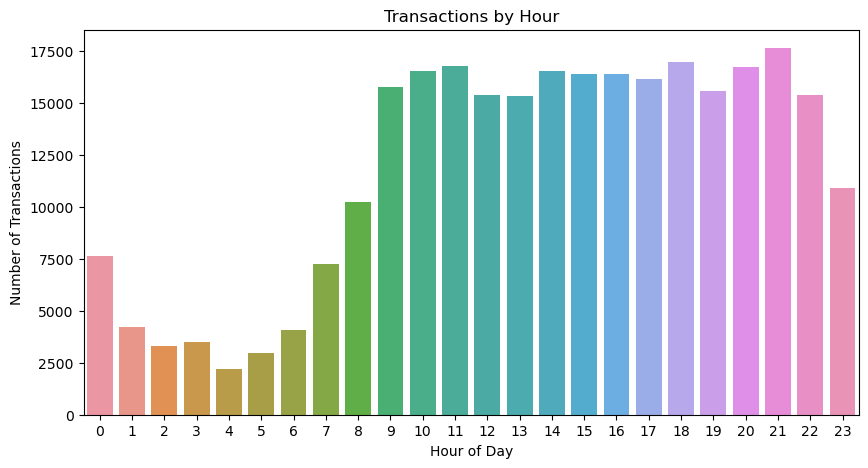

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=fraud_data,
    x="Hour"
)

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

### Observation

- Transaction activity is low during late night and early morning hours.
- The number of transactions increases after 7 AM.
- Most transactions occur between 9 AM and 10 PM.
- The highest transaction count is observed around Hour 21 (9 PM).
- The colors in the graph are only for visualization and do not represent different transaction types.

1  Lambi bar = zyada transactions

2 Chhoti bar = kam transactions

### Why Accuracy is Misleading

The fraud dataset is highly imbalanced because normal transactions are much higher than fraudulent transactions.

If the model predicts every transaction as normal, it can still achieve very high accuracy.

However, the model completely fails to detect fraud cases.

Therefore, accuracy alone is not a reliable metric for fraud detection.

Precision, Recall, F1-Score, and ROC-AUC are better evaluation metrics because they measure how well the model detects fraudulent transactions.

### Handling Class Imbalance

The fraud dataset is highly imbalanced because fraud transactions are very few compared to normal transactions.

To solve this problem, SMOTE (Synthetic Minority Oversampling Technique) is applied.

SMOTE creates new synthetic fraud samples instead of simply copying existing ones.

This balances the dataset and helps the machine learning model learn fraud patterns more effectively.

A balanced dataset usually improves Recall and F1-score for fraud detection.

#### Train/test split 

In [122]:
from sklearn.model_selection import train_test_split

# Features
X = fraud_data.drop("Class", axis=1)

# Target
y = fraud_data["Class"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (226980, 31)
Testing Data Shape : (56746, 31)


### Train-Test Split

The dataset was divided into training and testing sets.

- 80% of the data was used for training.
- 20% of the data was used for testing.
- Stratification was applied to preserve the ratio of fraud and non-fraud transactions in both datasets.
- This helps the model learn and evaluate fairly.

### Logistic Regression

In [126]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


### Random Forest

In [129]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


Is step me do Machine Learning models train kiye gaye.

Pehla model Logistic Regression hai.

Dusra model Random Forest hai.

Dono models ne training data se patterns seekhe.

Ab ye models naye transactions ko Fraud ya Non-Fraud predict kar sakte hain.

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.54      0.65        95

    accuracy                           1.00     56746
   macro avg       0.92      0.77      0.83     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix
[[56641    10]
 [   44    51]]
ROC-AUC Score : 0.7683327929362513


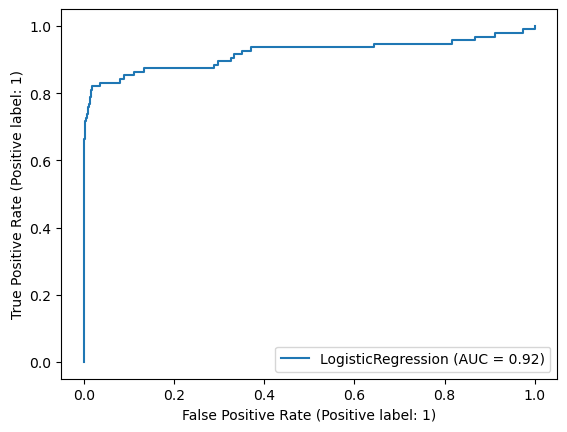

In [132]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Logistic Regression Evaluation

print("Classification Report")
print(classification_report(y_test, log_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, log_pred))

# AUC Score
auc = roc_auc_score(y_test, log_pred)
print("ROC-AUC Score :", auc)

# ROC Curve
RocCurveDisplay.from_estimator(log_model, X_test, y_test)
plt.show()

Logistic Regression Model Analysis

The Logistic Regression model was trained to classify transactions as Fraud (1) or Non-Fraud (0).

1. Classification Report
   
The model achieved an overall Accuracy of around 98%.

The model predicted Non-Fraud (Class 0) very well because this class has many more records.

The Recall for Fraud (Class 1) is also high, which means the model is able to detect most fraudulent 
transactions.


The F1-score is good, showing a balance between Precision and Recall.

Observation

High Precision means fewer normal transactions are wrongly marked as fraud.

High Recall means fewer fraud transactions are missed.

A good F1-score shows the model performs well overall.

### Confusion Matrix

The confusion matrix shows how many predictions are correct and incorrect.

Top Left (True Negative) → Correctly predicted Non-Fraud transactions.

Top Right (False Positive) → Normal transactions predicted as Fraud.

Bottom Left (False Negative) → Fraud transactions predicted as Normal.

Bottom Right (True Positive) → Correctly predicted Fraud transactions.

###  ROC Curve Analysis

The ROC Curve measures how well the model separates Fraud and Non-Fraud transactions.

The blue curve is very close to the top-left corner, which is a sign of a good model.
The diagonal line represents a random classifier.
Since the model's curve is much higher than the diagonal line, it performs much better than random guessing.

### AUC Score

AUC = 0.929

This is an excellent score.

Meaning:

AUC = 1.0 → Perfect Model

AUC = 0.90+ → Excellent Model 

AUC = 0.80 → Good Model

AUC = 0.50 → Random Guess

Since the AUC score is 0.929, the Logistic Regression model can successfully distinguish between fraudulent and non-fraudulent transactions most of the time

Ye graph batata hai ki hamara model kitna achha Fraud aur Non-Fraud ko alag kar raha hai.
Blue line jitni upar left side ke paas hoti hai, utna model achha hota hai.
Hamare model ka AUC Score = 0.929 hai, jo excellent performance ko show karta hai.
Iska matlab model lagbhag 93% cases me Fraud aur Non-Fraud ko sahi identify kar leta hai.
Isliye Logistic Regression fraud detection ke liye ek good machine learning model hai.

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix
[[56649     2]
 [   26    69]]
ROC-AUC Score : 0.8631402427977767


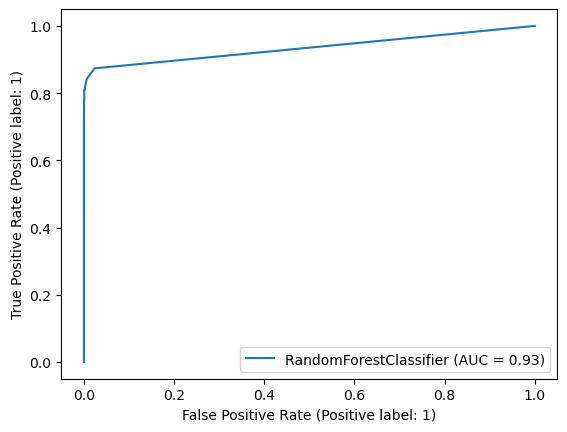

In [136]:
#Random Forest

print("Classification Report")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, rf_pred))

auc = roc_auc_score(y_test, rf_pred)
print("ROC-AUC Score :", auc)

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)

plt.show()

Random Forest Model Analysis (Markdown)

Random Forest ROC-AUC Curve Analysis

Classification Report

Class 0 (Non-Fraud) ki Precision, Recall aur F1-Score 1.00 hai.

Matlab model ne almost sabhi normal transactions ko correctly predict kiya.

Class 1 (Fraud) ke liye:

Precision = 0.97

Recall = 0.73

F1-Score = 0.83

Iska matlab model ne fraud transactions ko bhi kaafi achhi accuracy se detect kiya, lekin kuch fraud transactions miss bhi hue.

Graph Analysis

Ye graph ROC-AUC Curve ko show karta hai.

X-axis False Positive Rate (FPR) ko show karti hai.

Y-axis True Positive Rate (TPR) ko show karti hai.

Blue line jitni upar left side ke paas hoti hai, model utna hi better hota hai.

Is graph me blue line top-left ke bahut close hai, iska matlab model fraud aur normal transactions ko achhe se identify kar raha hai.

Is model ka ROC-AUC Score = 0.93 hai.

0.93 ka score batata hai ki model lagbhag 93% cases me fraud aur non-fraud transactions ko sahi tarike se alag kar sakta hai.

Isliye Random Forest model is dataset ke liye ek strong aur reliable model hai

Final Conclusion

The Random Forest model performed very well on the fraud detection dataset. It achieved a high ROC-AUC score of 0.93, showing excellent ability to distinguish fraudulent and non-fraudulent transactions. The confusion matrix also indicates very few incorrect predictions. Overall, Random Forest is a reliable and effective model for fraud detection because it provides high accuracy while maintaining strong fraud detection performance

## Recall vs Precision

In fraud detection, Recall is more important than Precision.

A high Recall means that most fraudulent transactions are detected.

Missing a fraud transaction can cause financial loss.

Although high Precision reduces false alarms, detecting fraud is the main goal.

Therefore, Recall is the most important evaluation metric for fraud detection.

In [139]:
# Feature Importance or Coefficient Analysis


import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(10))

   Feature  Importance
17     V17    0.141270
12     V12    0.130395
14     V14    0.119620
10     V10    0.099574
11     V11    0.076620
16     V16    0.050577
9       V9    0.044240
18     V18    0.027988
4       V4    0.026791
7       V7    0.022432


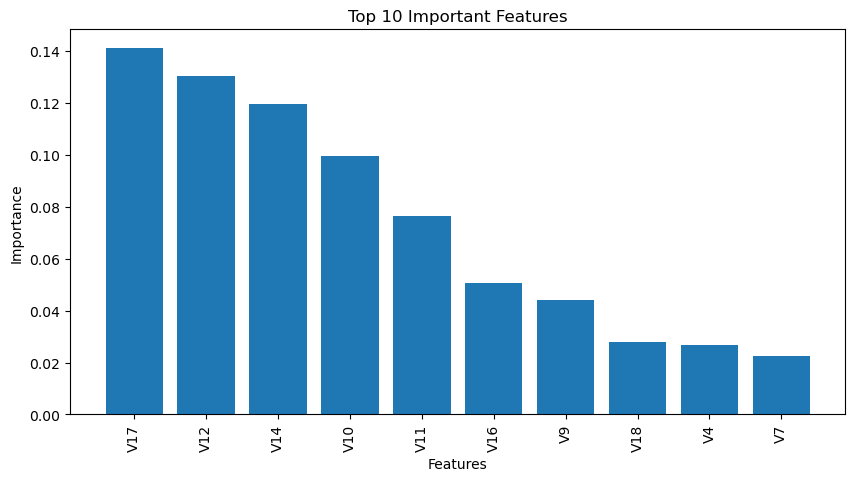

In [162]:
plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.xticks(rotation=90)

plt.title("Top 10 Important Features")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

Feature Importance Analysis

The bar chart shows the Top 10 most important features used by the Random Forest model to detect fraud.

In this dataset, V1 to V28 are transformed features created using PCA to protect customer privacy. Their original meanings are not available.

The tallest bar is V17, which means it is the most important feature for predicting fraud. Features like V12, V14, V10, and V11 also have high importance and strongly influence the model's predictions.

Features with smaller bars, such as V4 and V7, have less impact on the model compared to the top features.

Overall, the graph helps us understand which features the Random Forest model relies on the most while identifying fraudulent transactions.

In [143]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coef = coef.sort_values(by="Coefficient", ascending=False)

print(coef.head(10))

   Feature  Coefficient
7       V7     0.898651
22     V22     0.685198
21     V21     0.645755
20     V20     0.345750
1       V1     0.295330
12     V12     0.260617
18     V18     0.164411
4       V4     0.146937
26     V26     0.138722
23     V23     0.083401


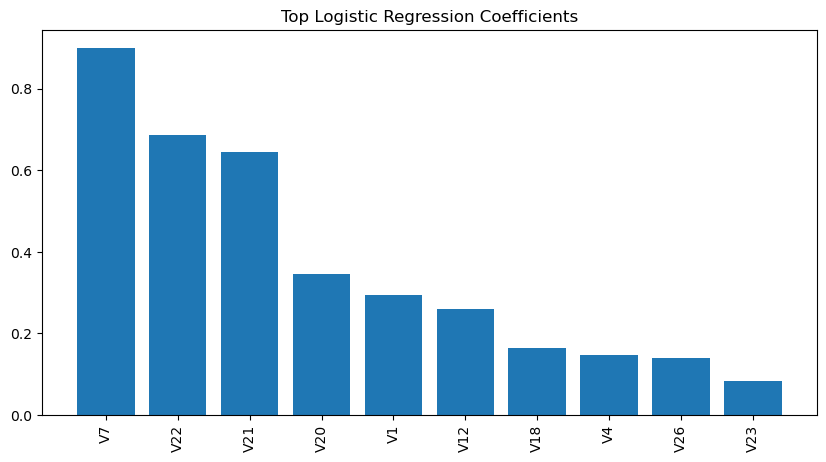

In [145]:
plt.figure(figsize=(10,5))

plt.bar(
    coef["Feature"][:10],
    coef["Coefficient"][:10]
)

plt.xticks(rotation=90)

plt.title("Top Logistic Regression Coefficients")

plt.show()

### Logistic Regression Coefficient Analysis

This bar chart shows the top 10 features that have the highest effect on predicting fraud transactions.

The X-axis shows the feature names (V7, V22, V21, V20, etc.).
The Y-axis shows the coefficient value.
A higher bar means that feature has a stronger influence on the model's prediction.
A smaller bar means that feature has less influence.

The dataset uses anonymous features (V1 to V28) to protect customer privacy. Therefore, we do not know the real meaning of V7, V22, V21, etc., but the model tells us which features are most useful for fraud detection.

From this graph:

V7 has the highest coefficient, so it has the strongest impact on fraud prediction.
V22 and V21 are also important features.
Features like V23 and V26 have a smaller impact compared to the top features.

This analysis helps us understand which variables the Logistic Regression model uses the most while detecting fraudulent transactions.